In [1]:
import joblib 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
# models
cox_model = joblib.load(r'C:\Users\Dev\OneDrive\Desktop\data\Survival Analysis\cox_model')
xgb_model = joblib.load(r'C:\Users\Dev\OneDrive\Desktop\data\Survival Analysis\xgb_model')

In [3]:
# CT
cox_model_ct = joblib.load(r'C:\Users\Dev\OneDrive\Desktop\data\Survival Analysis\CT_cox_model')
xgb_model_ct = joblib.load(r'C:\Users\Dev\OneDrive\Desktop\data\Survival Analysis\CT_xgb_model')

In [4]:
## XGB PIPE 
xgb_pipe = joblib.load(r'C:\Users\Dev\OneDrive\Desktop\data\Survival Analysis\xgb_pipeline')

In [5]:
# Data for xgb and cox 
df = pd.read_csv(r'C:\Users\Dev\OneDrive\Desktop\data\Survival Analysis\Data_for_xgb_model.csv').iloc[:,1:]

In [6]:
df.columns

Index(['loan_amnt', 'term', 'int_rate', 'sub_grade', 'home_ownership',
       'annual_inc', 'verification_status', 'dti', 'delinq_2yrs',
       'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record',
       'open_acc', 'pub_rec', 'revol_bal', 'total_acc', 'initial_list_status',
       'mths_since_last_major_derog', 'Duration', 'Event', 'Employement',
       'purpose_group', 'Duration_encoded'],
      dtype='object')

In [7]:
cox_model_ct

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Ordinal_enc', ...), ('Nominla_enc', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer

In [8]:

# Example: predict risk score for one row
n = np.random.randint(0, df.shape[0]-1)

X_new = df.iloc[[n], :].drop(columns=['Duration','Event','Duration_encoded'])

# Apply the same preprocessing pipeline you used for training
X_new_transformed = cox_model_ct.transform(X_new)

# Predict risk score (partial hazard)
risk_score = cox_model.predict_partial_hazard(pd.DataFrame(X_new_transformed, columns=cox_model_ct.get_feature_names_out()))
print(risk_score)


# XGB MODEL 
# Example: predict risk score for one row
X_new = df.iloc[[n], :].drop(columns=['Duration','Event','Duration_encoded'])

# Apply the same preprocessing pipeline you used for training
X_new_transformed = xgb_model_ct.transform(X_new)

# Predict risk score (
risk_score = xgb_model.predict(X_new_transformed)
print(risk_score)


0    0.480315
dtype: float64
[0.4093111]


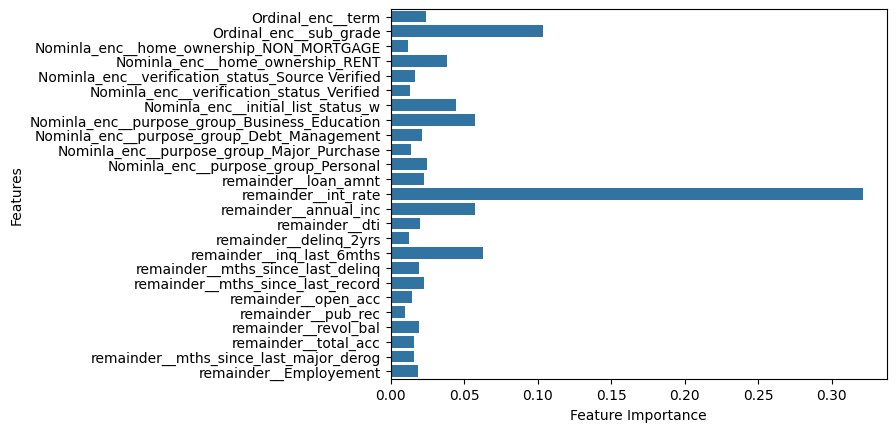

,Feature,Importance
12,remainder__int_rate,0.321218
1,Ordinal_enc__sub_grade,0.103888
16,remainder__inq_last_6mths,0.062543
7,Nominla_enc__purpose_group_Business_Education,0.057256
13,remainder__annual_inc,0.057164
6,Nominla_enc__initial_list_status_w,0.044638
3,Nominla_enc__home_ownership_RENT,0.038327
10,Nominla_enc__purpose_group_Personal,0.024592
0,Ordinal_enc__term,0.024075
18,remainder__mths_since_last_record,0.022684


In [9]:
sns.barplot(x=xgb_model.feature_importances_, y=xgb_model_ct.get_feature_names_out())
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.show()
pd.DataFrame({'Feature': xgb_model_ct.get_feature_names_out(), 'Importance': xgb_model.feature_importances_}).sort_values(by='Importance', ascending=False).head(10)

### Interpretation of XGBoost Feature Importance

The feature importance plot ranks predictors according to their contribution to the XGBoost Survival model during tree construction. Features with higher importance values are used more frequently to reduce the model's loss.

**Key Observations**

- **Interest Rate** is the most influential predictor with a feature importance of **0.3212**, indicating that it plays the largest role in separating borrowers based on default risk.
- **Sub Grade** is the second most important feature (**0.1039**), confirming that the assigned credit grade is a strong indicator of survival probability.
- **Credit Inquiries in the Last 6 Months** (**0.0625**) and **Annual Income** (**0.0572**) are also important predictors, suggesting that recent borrowing behaviour and borrower income significantly influence risk estimation.
- **Purpose Group (Business/Education)** (**0.0573**) and **Initial List Status** (**0.0446**) provide moderate predictive information to the model.
- **Home Ownership (RENT)** (**0.0383**), **Purpose Group (Personal)** (**0.0246**), **Loan Term** (**0.0241**), and **Months Since Last Record** (**0.0227**) have relatively smaller but meaningful contributions.
- The remaining predictors have low importance values, indicating that they contribute only marginally to the model's predictive performance.


# Using shapely values for XGB Model

In [10]:
import sys
from types import ModuleType
from unittest.mock import MagicMock

class DynamicNumbaModule(ModuleType):
    """Dynamically creates submodules on the fly so 'import numba.X.Y' never fails."""
    def __getattr__(self, name):
        if name in ("njit", "jit", "generated_jit"):
            # Passthrough decorator for functions
            return lambda *args, **kwargs: (
                args[0] if args and callable(args[0]) else (lambda f: f)
            )
        # Return a nested dynamic module for any subpackage access
        submodule = DynamicNumbaModule(f"{self.__name__}.{name}")
        setattr(self, name, submodule)
        return submodule

# Create the top-level mock
numba_mock = DynamicNumbaModule("numba")
numba_mock.typed = DynamicNumbaModule("numba.typed")
numba_mock.core = DynamicNumbaModule("numba.core")

# Inject into sys.modules
sys.modules["numba"] = numba_mock
sys.modules["numba.typed"] = numba_mock.typed
sys.modules["numba.core"] = numba_mock.core

# Intercept any future nested numba imports dynamically
class NumbaFinder:
    def find_spec(self, fullname, path, target=None):
        if fullname.startswith("numba"):
            from importlib.machinery import ModuleSpec
            return ModuleSpec(fullname, None, loader=NumbaLoader(fullname))
        return None

class NumbaLoader:
    def __init__(self, name):
        self.name = name
    def create_module(self, spec):
        return DynamicNumbaModule(self.name)
    def exec_module(self, module):
        pass

sys.meta_path.insert(0, NumbaFinder())

# Now try importing SHAP!
import shap
print("Successfully imported SHAP without Numba DLL execution!")

Successfully imported SHAP without Numba DLL execution!


In [11]:
from sklearn.model_selection import train_test_split

train, test= train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["Event"]   
    )


In [12]:
# Tree Explainer for XGB model 
explainer = shap.TreeExplainer(xgb_model) 
X_new_transformed = pd.DataFrame(xgb_model_ct.transform(test.drop(columns=['Duration','Event','Duration_encoded'], axis =1 )), columns=xgb_model_ct.get_feature_names_out())
shap_values = explainer(X_new_transformed)

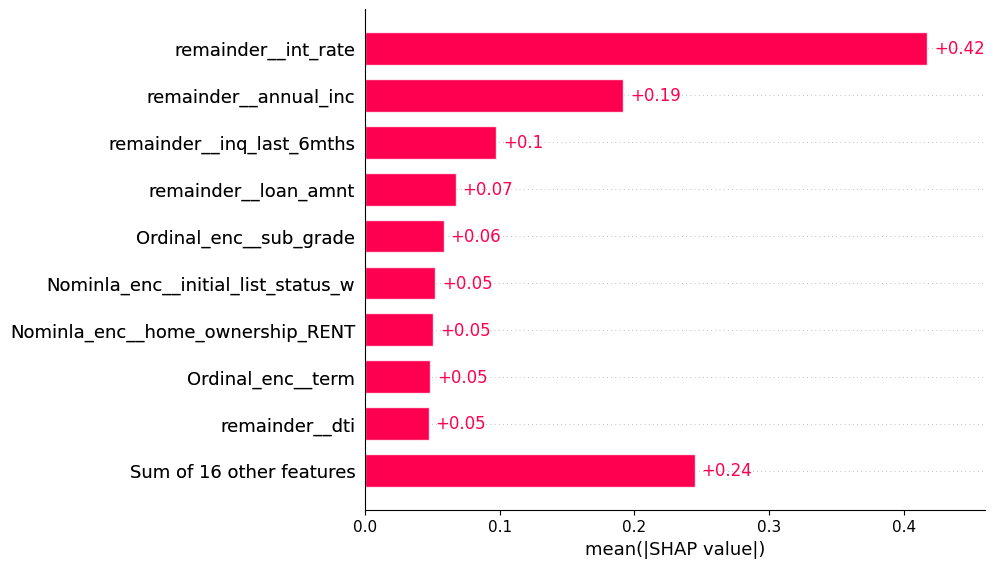

In [13]:
# Bar plot 
shap.plots.bar(shap_values = shap_values,max_display=10)

### Interpretation of SHAP Feature Importance (Bar Plot)

The SHAP bar plot ranks features based on their **average contribution** to the model prediction.

**Key Observations**

- **Interest Rate** has the highest mean SHAP value (**0.42**), indicating that changes in interest rate have the largest influence on the predicted default risk.
- **Annual Income** has the second highest contribution (**0.19**), showing that borrower income strongly affects the model predictions.
- **Credit Inquiries in the Last 6 Months (0.10)** and **Loan Amount (0.07)** moderately influence the predicted risk.
- **Sub Grade (0.06)**, **Initial List Status (0.05)**, **Home Ownership (RENT) (0.05)**, **Loan Term (0.05)** and **DTI (0.05)** contribute less individually but remain important predictors.
- The remaining **16 features** together contribute approximately **0.24**, indicating that while individually less influential, they collectively improve the model's predictive capability.

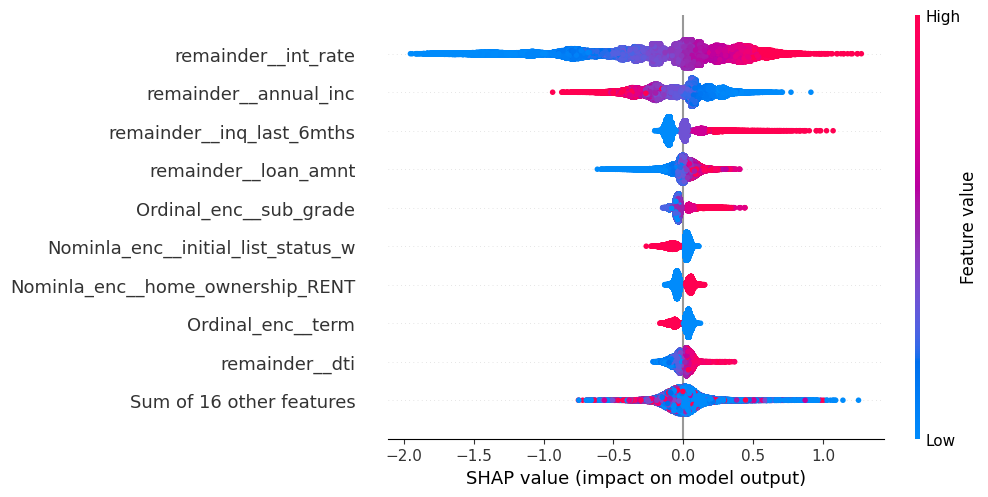

In [14]:
# Bee swarm plot 
shap.plots.beeswarm(shap_values = shap_values, max_display=10)

### Interpretation of SHAP Beeswarm Plot

The SHAP beeswarm plot illustrates how different feature values increase or decrease the predicted default risk for individual borrowers.

**Key Observations**

- Higher **Interest Rates** (red points) generally produce **positive SHAP values**, increasing the predicted default risk, whereas lower interest rates (blue points) reduce the risk.
- Higher **Annual Income** generally results in **negative SHAP values**, lowering the predicted risk, while lower incomes increase it.
- A larger number of **Credit Inquiries in the Last 6 Months** pushes the model toward a higher predicted default risk.
- Higher **Loan Amounts** and poorer **Sub Grades** also tend to increase the predicted risk, although their effect is smaller than that of interest rate.
- **Initial List Status**, **Home Ownership (RENT)**, **Loan Term**, and **DTI** exhibit relatively smaller but consistent impacts on the model predictions.

### Unified Credit Risk Prediction Function

A unified prediction function will be developed to automate the complete inference pipeline for a single borrower. The function will accept the borrower's financial and demographic information as input, apply the same preprocessing pipeline used during model training, and generate predictions from all trained credit risk models. This ensures that every prediction is performed using identical feature engineering and preprocessing steps as those employed during model development.

The function will perform the following tasks:

- Accept borrower information as function inputs.
- Convert the inputs into a single-row DataFrame.
- Apply the trained **ColumnTransformer** to preprocess the data.
- Predict the **probability of default** using the Logistic Regression model.
- Predict the **probability of default** using the Gradient Boosting model.
- Estimate the borrower's **risk score (hazard)** using the Cox Proportional Hazards model.
- Estimate the borrower's **risk score** using the XGBoost Survival model.
- Compute **SHAP values** for the XGBoost prediction.
- Display a **SHAP Waterfall Plot** explaining the contribution of each feature to the predicted risk.
- Return all prediction results in a structured format for further visualization or deployment.

This function serves as the core prediction engine and will subsequently be integrated into a **Streamlit-based interactive dashboard**, allowing users to obtain classification, survival analysis, and model explainability results through a single interface.

In [15]:
# Preprocessing pipeline
preprocessing = joblib.load(r'C:\Users\Dev\OneDrive\Desktop\data\phase3_modelling\Ct_for_preprocessing')

#Models
lr = joblib.load(r'C:\Users\Dev\OneDrive\Desktop\data\phase3_modelling\Final_lr_model')
gb = joblib.load(r'C:\Users\Dev\OneDrive\Desktop\data\phase3_modelling\Final_gb_model')

In [16]:
X_test = pd.read_csv(r'C:\Users\Dev\OneDrive\Desktop\data\phase4_Models_evalutaion\Evaluation_Ready_data.csv')
X_test = X_test.iloc[:,1:]


In [17]:
preprocessing.feature_names_in_

array(['loan_amnt', 'term', 'sub_grade', 'home_ownership',
       'verification_status', 'purpose_group', 'delinq_2yrs_flag',
       'inq_last_6mths_bin', 'total_acc_bin', 'emp_status_unverifiable',
       'bin_annual_inc', 'bin_int_ratec', 'bin_dti', 'bin_revol_util'],
      dtype=object)

In [18]:
X_test.columns

Index(['ord_enc__term', 'ord_enc__sub_grade', 'ord_enc__inq_last_6mths_bin',
       'ord_enc__total_acc_bin', 'ord_enc__bin_annual_inc',
       'ord_enc__bin_int_ratec', 'ord_enc__bin_dti', 'ord_enc__bin_revol_util',
       'nom_enc__home_ownership_OWN', 'nom_enc__home_ownership_RENT',
       'nom_enc__home_ownership_UNSPECIFIED',
       'nom_enc__verification_status_Source Verified',
       'nom_enc__verification_status_Verified',
       'nom_enc__purpose_group_Debt Management',
       'nom_enc__purpose_group_Home & Property',
       'nom_enc__purpose_group_Personal Expenses',
       'nom_enc__purpose_group_Vehicle & Major Purchases',
       'scaling__loan_amnt', 'remainder__delinq_2yrs_flag',
       'remainder__emp_status_unverifiable'],
      dtype='object')

In [19]:
test.columns

Index(['loan_amnt', 'term', 'int_rate', 'sub_grade', 'home_ownership',
       'annual_inc', 'verification_status', 'dti', 'delinq_2yrs',
       'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record',
       'open_acc', 'pub_rec', 'revol_bal', 'total_acc', 'initial_list_status',
       'mths_since_last_major_derog', 'Duration', 'Event', 'Employement',
       'purpose_group', 'Duration_encoded'],
      dtype='object')

In [20]:
preprocessing.named_transformers_

{'ord_enc': OrdinalEncoder(categories=[array([' 36 months', ' 60 months'], dtype=object),
                            array(['A1', 'A2', 'A3', 'A4', 'A5', 'B1', 'B2', 'B3', 'B4', 'B5', 'C1',
        'C2', 'C3', 'C4', 'C5', 'D1', 'D2', 'D3', 'D4', 'D5', 'E1', 'E2',
        'E3', 'E4', 'E5', 'F1', 'F2', 'F3', 'F4', 'F5', 'G1', 'G2', 'G3',
        'G4', 'G5'], dtype=object),
                            array(['0', '0-1', '1-2', '2+'], dtype=object),
                            array(['0-10', '10-16', '16-20', '20-26', '26-35', '35+'], dtype=object),
                            ['<18K', '18K-40K', '40K-80K', '80K-120K', '>120K'],
                            ['<8%', '8-12%', '12-15%', '15-21%', '21-24%',
                             '>24%'],
                            ['<5', '5-10', '10-15', '15-20', '20-25', '25-30',
                             '30-35', '>35'],
                            ['<20%', '20-40%', '40-60%', '60-80%', '80-100%',
                             '>100%']]),
 'nom_enc

In [21]:
print(X_test.sample(5).to_string())
print(test.sample(5).to_string())

       ord_enc__term  ord_enc__sub_grade  ord_enc__inq_last_6mths_bin  ord_enc__total_acc_bin  ord_enc__bin_annual_inc  ord_enc__bin_int_ratec  ord_enc__bin_dti  ord_enc__bin_revol_util  nom_enc__home_ownership_OWN  nom_enc__home_ownership_RENT  nom_enc__home_ownership_UNSPECIFIED  nom_enc__verification_status_Source Verified  nom_enc__verification_status_Verified  nom_enc__purpose_group_Debt Management  nom_enc__purpose_group_Home & Property  nom_enc__purpose_group_Personal Expenses  nom_enc__purpose_group_Vehicle & Major Purchases  scaling__loan_amnt  remainder__delinq_2yrs_flag  remainder__emp_status_unverifiable
40031            0.0                10.0                          1.0                     2.0                      3.0                     2.0               2.0                      2.0                          0.0                           1.0                                  0.0                                           0.0                                    1.0          

Inputs


c:\Users\Dev\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\Dev\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
Background dataset has 46058 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=46058 when initializing the masker.


LR model prediction: 51.28431786637544 % Default probability
GB model prediction: 34.67704907309991 % Default probability


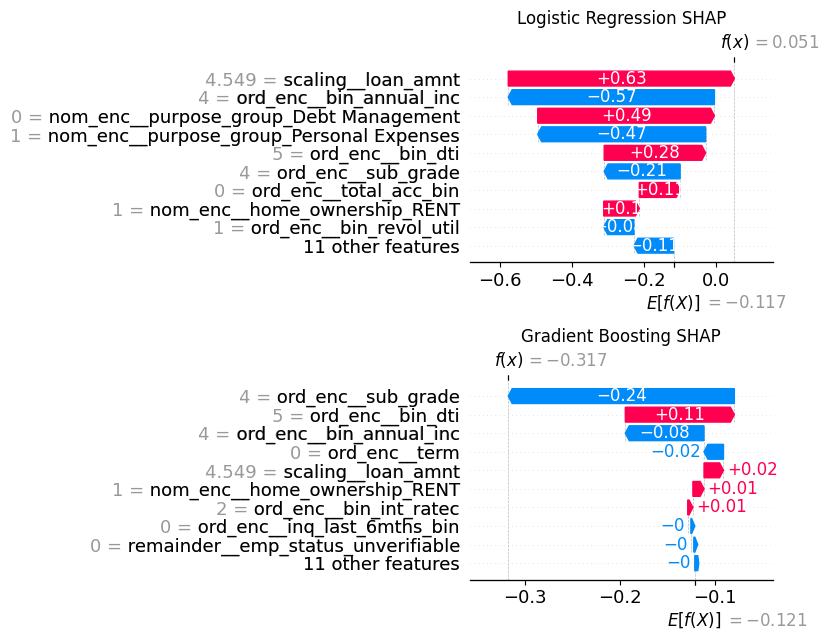

Cox model risk prediction: 0.4784885272030309


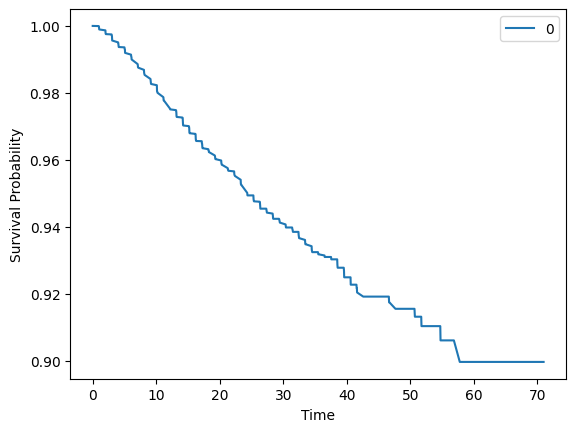

In [ ]:
print('Inputs')
loan_amnt = int(input('Input loan amount: '))
term = int(input('Input term " 36 months" = 0, " 60 months" = 1: '))
if term == 0:
    term = ' 36 months'
else:
    term = ' 60 months'
    
int_rate = float(input('Input interest rate (float): '))
sub_grade = input('Input sub grade (e.g. A1, B2, C3,..., upto G5): ')
home_ownership = int(input('Input home ownership (e.g. RENT = 0, OWN = 1, MORTGAGE = 2, OTHER = 3): '))
if home_ownership == 0:
    home_ownership = 'RENT'
elif home_ownership == 1:
    home_ownership = 'OWN'
elif home_ownership == 2:
    home_ownership = 'MORTGAGE'
elif home_ownership == 3:
    home_ownership = 'OTHER'

annual_inc = float(input('Input annual income (float): '))

verification_status = int(input('Input verification status (e.g. Verified = 0, Not Verified = 1, Source Verified = 2): '))
if verification_status == 0:
    verification_status = 'Verified'
elif verification_status == 1:
    verification_status = 'Not Verified'
elif verification_status == 2:
    verification_status = 'Source Verified'

dti = float(input('Input debt to income ratio (float): '))
delinq_2yrs = int(input('Input number of delinquencies in the past 2 years (eg 0, 1, 2, ...): '))
inq_last_6mths  = int(input('Input number of inquiries in the last 6 months (eg 0, 1, 2, ...): '))
total_acc = int(input('Input total number of accounts (eg 0, 1, 2, ...): '))
revol_util = float(input('Input revolving utilization (float): '))
revol_bal = float(input('Input revolving balance (float): '))
open_acc = int(input('Input number of open accounts (eg 0, 1, 2, ...): '))
pub_rec = int(input('Input number of public records (eg 0, 1, 2, ...): '))
mths_since_last_delinq = int(input('Input months since last delinquency (eg 0, 1, 2, ...): '))
mths_since_last_record  = int(input('Input months since last public record (eg 0, 1, 2, ...): '))
mths_since_last_major_derog = int(input('Input months since last major derogatory (eg 0, 1, 2, ...): '))
initial_list_status = input('Input initial list status (e.g. f, w): ')
emp_status_unverifiable = int(input('Input employment status (e.g. 0 for unverifiable, 1 for verified): '))
purpose_group = int(input('Input purpose group (e.g. Debt Management = 0, Home & Property = 1, Personal Expenses = 2, Business & Education = 3, Vehicle & Major Purchases = 4): '))
if purpose_group == 0:
    purpose_group = 'Debt Management'
elif purpose_group == 1:
    purpose_group = 'Home & Property'
elif purpose_group == 2:
    purpose_group = 'Personal Expenses'
elif purpose_group == 3:
    purpose_group = 'Business & Education'
elif purpose_group == 4:
    purpose_group = 'Vehicle & Major Purchases'

delinq_2yrs_flag = int(input('Input delinq_2yrs_flag (0 or 1): '))


input_data = pd.DataFrame({
    'loan_amnt': [loan_amnt],
    'term': [term],
    'int_rate': [int_rate],
    'sub_grade': [sub_grade],
    'home_ownership': [home_ownership],
    'annual_inc': [annual_inc],
    'verification_status': [verification_status],
    'dti': [dti],
    'delinq_2yrs': [delinq_2yrs],
    'inq_last_6mths': [inq_last_6mths],
    'total_acc': [total_acc],
    'revol_util': [revol_util],
    'revol_bal': [revol_bal],
    'open_acc': [open_acc],
    'pub_rec': [pub_rec],
    'mths_since_last_delinq': [mths_since_last_delinq],
    'mths_since_last_record': [mths_since_last_record],
    'mths_since_last_major_derog': [mths_since_last_major_derog],
    'initial_list_status': [initial_list_status],
    'emp_status_unverifiable': [emp_status_unverifiable],
    'purpose_group': [purpose_group],
    'delinq_2yrs_flag': [delinq_2yrs_flag]
})

# Default prediction LR model
lr_model_input = input_data.copy()

lr_model_input['bin_annual_inc'] = pd.cut(
    lr_model_input['annual_inc'],
    bins=[-1, 18000, 40000, 80000, 120000, float('inf')],
    labels=['<18K', '18K-40K', '40K-80K', '80K-120K', '>120K'],
    include_lowest=True
)

lr_model_input['inq_last_6mths_bin'] = pd.cut(
    lr_model_input['inq_last_6mths'],
    bins=[-1, 0, 1, 2, float('inf')],
    labels=['0', '0-1', '1-2', '2+'],
    include_lowest=True
)

lr_model_input['total_acc_bin'] = pd.cut(
    lr_model_input['total_acc'],
    bins=[-1, 10, 16, 20, 26, 35, float('inf')],
    labels=['0-10', '10-16', '16-20', '20-26', '26-35', '35+'],
    include_lowest=True
)

lr_model_input['bin_int_ratec'] = pd.cut(
    lr_model_input['int_rate'],
    bins=[-1, 8, 12, 15, 21, 24, float('inf')],
    labels=['<8%', '8-12%', '12-15%', '15-21%', '21-24%', '>24%'],
    include_lowest=True
)

lr_model_input['bin_dti'] = pd.cut(
    lr_model_input['dti'],
    bins=[-1, 5, 10, 15, 20, 25, 30, 35, float('inf')],
    labels=['<5', '5-10', '10-15', '15-20', '20-25', '25-30', '30-35', '>35'],
    include_lowest=True
)

lr_model_input['bin_revol_util'] = pd.cut(
    lr_model_input['revol_util'],
    bins=[-1, 20, 40, 60, 80, 100, float('inf')],
    labels=['<20%', '20-40%', '40-60%', '60-80%', '80-100%', '>100%'],
    include_lowest=True
)

# Drop original continuous variables
lr_model_input.drop(['annual_inc', 'inq_last_6mths', 'total_acc', 'int_rate', 'dti', 'revol_util'], axis=1, inplace=True)

# LR model
print('LR model prediction:' , lr.predict_proba(preprocessing.transform(lr_model_input))[:, 1][0]*100, '% Default probability')

# Default prediction GB model
print('GB model prediction:' , gb.predict_proba(preprocessing.transform(lr_model_input))[:, 1][0]*100, '% Default probability')

# Transform input
X_trans = pd.DataFrame(
    preprocessing.transform(lr_model_input),
    columns=preprocessing.get_feature_names_out()
)

# Masker for SHAP
masker = shap.maskers.Independent(X_test, max_samples=100)

# Compute SHAP values
shap_lr = shap.LinearExplainer(lr, masker)(X_trans)
shap_gb = shap.TreeExplainer(gb, masker)(X_trans)

# Create subplots
fig, axes = plt.subplots(2 ,1, figsize=(6, 16))

# LR waterfall plot
plt.sca(axes[0])  # set current axis
shap.plots.waterfall(shap_lr[0], max_display=10, show=False)
axes[0].set_title("Logistic Regression SHAP")

# GB waterfall plot
plt.sca(axes[1])  # set current axis
shap.plots.waterfall(shap_gb[0], max_display=10, show=False)
axes[1].set_title("Gradient Boosting SHAP")

plt.tight_layout()
plt.show()


# --- Survival analysis (Cox model) ---
cox_model_input = input_data.copy()

# Collapse sub_grade into letter groups
for grade in ['A','B','C','D','E','F','G']:
    cox_model_input.loc[cox_model_input['sub_grade'].str.startswith(grade), 'sub_grade'] = grade

# renaming purpose_group labels to match the training data
cox_model_input.loc[cox_model_input['purpose_group'] == 'Debt Management', 'purpose_group'] = 'Debt_Management'
cox_model_input.loc[cox_model_input['purpose_group'] == 'Business & Education', 'purpose_group'] = 'Business_Education'
cox_model_input.loc[cox_model_input['purpose_group'] == 'Personal Expenses', 'purpose_group'] = 'Personal'
cox_model_input.loc[cox_model_input['purpose_group'] == 'Home & Property', 'purpose_group'] = 'Asset_Home'
cox_model_input.loc[cox_model_input['purpose_group'] == 'Vehicle & Major Purchases', 'purpose_group'] = 'Major_Purchase'

# renaming home_ownership elements to match the training data
cox_model_input.loc[cox_model_input['home_ownership'].isin(['OTHER','OWN']), 'home_ownership'] = 'NON_MORTGAGE'

cox_model_input['term']  = cox_model_input['term'].str.strip()  # Remove leading/trailing spaces from 'term' column 

# Rename employment column
cox_model_input.rename(columns={'emp_status_unverifiable':'Employement'}, inplace=True)

# Risk prediction
cox_transformed = pd.DataFrame(cox_model_ct.transform(cox_model_input),
                               columns=cox_model_ct.get_feature_names_out())
print('Cox model risk prediction:', cox_model.predict_partial_hazard(cox_transformed)[0])
# Get survival function for the sample input
surv_func = cox_model.predict_survival_function(cox_transformed)
surv_func.plot(kind = 'line')
plt.xlabel('Time')
plt.ylabel('Survival Probability')
plt.show()


# Survival analysis (XGB model)
xgb_model_input = cox_model_input.copy()
xgb_transformed = pd.DataFrame(xgb_model_ct.transform(xgb_model_input),
                               columns=xgb_model_ct.get_feature_names_out())
print('XGB model risk prediction:', xgb_model.predict(xgb_transformed)[0])

# Shap values for XGB model
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(xgb_transformed)
shap.plots.waterfall(shap_values[0], max_display=10, show=True)

raw_score = shap_values.base_values[0]  + shap_values.values[0].sum()  # Calculate the raw score by adding base value and SHAP values
print("Raw score :", raw_score)
print("exp(raw)  :", np.exp(raw_score))
print("Prediction:", xgb_model.predict(xgb_transformed)[0])


The score is a relative measure of default risk. A higher score indicates that the borrower is expected to default earlier than borrowers with lower scores. In the Cox model, the risk score equals the hazard ratio relative to the baseline. In the XGBoost survival model, it is a relative ranking score rather than a directly interpretable hazard ratio